In [1]:
%matplotlib widget

In [2]:
import numpy as np
from scipy.interpolate import PPoly
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from plotbin.display_pixels import display_pixels 
import pandas as pd
from astropy.io import fits
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from astropy.convolution import Gaussian1DKernel
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [3]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    return 0.61 / (x - 0.05) + 1.3

def Ke01(x):
    # AGN selection based on Kewley et al. 2001
    return 0.61 / (x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
    return 0.29 / (x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48
    
def inverse_kewley(y):
    return (0.051 + 0.47 * y) / (y - 1.19)

def inverse_kauffmann(y):
    return (0.05 * y + 0.545) / (y - 1.3)

def inverse_stasinska(y):
    return 0.29 / (y - 0.96) - 0.20

def classify_BPT(N2Ha, O3Hb):  # log
    mask = np.zeros(N2Ha.shape[0], dtype=int)
    for i in range(N2Ha.shape[0]):
        x_kewley = inverse_kewley(O3Hb[i])
        x_kauffmann = inverse_kauffmann(O3Hb[i])
        x_stasinska = inverse_stasinska(O3Hb[i])

        if N2Ha[i] < x_stasinska: 
            mask[i] = 1  # SF
        elif N2Ha[i] >= x_stasinska and N2Ha[i] < x_kauffmann:
            mask[i] = 2  # weak composite
        elif N2Ha[i] >= x_kauffmann and N2Ha[i] < x_kewley:
            mask[i] = 3  # strong composite
        elif N2Ha[i] >= x_kewley:
            mask[i] = 4  # AGN
        else:
            mask[i] = np.nan

    mask[O3Hb > 1] = 4  # AGN if OIII/Hb > 1
    return mask

def plotBPT(N2Ha, O3Hb, OIII_HB_err, NII_HA_err):
    mask = classify_BPT(N2Ha, O3Hb)
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(1, 1, 1)
    ax.errorbar(N2Ha[mask == 1], O3Hb[mask == 1], yerr = OIII_HB_err[mask==1], xerr = NII_HA_err[mask==1], color ='blue', linestyle = 'none', markersize = 4, marker = 'o', label = 'SF') 
    ax.errorbar(N2Ha[mask == 2], O3Hb[mask == 2], yerr = OIII_HB_err[mask==2], xerr = NII_HA_err[mask==2], color ='yellow',  linestyle = 'none', markersize = 4, marker = 'o', label = 'Weak composite')
    ax.errorbar(N2Ha[mask == 3], O3Hb[mask == 3], yerr = OIII_HB_err[mask==3], xerr = NII_HA_err[mask==3], color ='orange', linestyle = 'none', markersize = 4, marker = 'o', label = 'Strong composite') 
    ax.errorbar(N2Ha[mask == 4], O3Hb[mask == 4], yerr = OIII_HB_err[mask==4], xerr = NII_HA_err[mask==4], color ='green', linestyle = 'none', markersize = 4, marker = 'o', label = 'AGN') 

    x = np.linspace(-2, 0.04, num=200)
    x1 = np.linspace(-2, 0.457, num=200)
    x2 = np.linspace(-2, -0.25, num=200)
    x3 = np.linspace(-0.49, 5, num=200)
    plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
    plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
    plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
    plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')

    ax.set_ylim(-1, 1.5)
    ax.set_xlim(-2, 0.5)
    plt.legend()
    plt.show()
    plt.savefig('BPT_1s_color')

def compute_dKauff(x1, y1):  # Distanza dalla curva di Kauffmann
    x = np.linspace(-2, 1.0, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.61 / (x - 0.05) + 1.3))**2)
    return np.min(distance)

def compute_dKewley(x1, y1):  # Distanza dalla curva di Kewley
    x = np.linspace(-2, 2, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.61 / (x - 0.47) + 1.19))**2)
    return np.min(distance)

def compute_dStasinska(x1, y1):  # Distanza dalla curva di Stasinska
    x = np.linspace(-2, 1, 10000)
    distance = np.sqrt((x1 - x)**2 + (y1 - (0.29 / (x + 0.20) + 0.96))**2)
    return np.min(distance)

def compute_eta(N2Ha, O3Hb):
    """
    Calcola eta con un gradiente più sfumato basato sulla distanza dalle curve.
    
    eta varia da -1 (fortemente SF) a +1 (fortemente AGN)
    Il gradiente è ora continuo e proporzionale alla distanza dalle curve
    anche all'interno di ogni regione del BPT.
    """
    mask = classify_BPT(N2Ha, O3Hb)
    eta = np.zeros(mask.shape[0])

    for i in range(mask.shape[0]):
        d_stasinska = compute_dStasinska(N2Ha[i], O3Hb[i])
        d_kauffmann = compute_dKauff(N2Ha[i], O3Hb[i])
        d_kewley = compute_dKewley(N2Ha[i], O3Hb[i])
        
        if mask[i] == 1:  # Star-forming
            # Varia da -1 (vicino a Stasinska, più SF puro) a valori più alti (lontano, meno SF)
            # Invertiamo: più sei lontano da Stasinska (verso il basso), più sei SF puro
            eta[i] = -0.5 - 0.5 * (1 - np.exp(-d_stasinska * 3))
            
        elif mask[i] == 2:  # Weak composite
            # Varia linearmente da -0.5 (vicino a Stasinska) a 0 (vicino a Kauffmann)
            total_dist = d_stasinska + d_kauffmann
            if total_dist > 0:
                eta[i] = -0.5 + 0.5 * (d_stasinska / total_dist)
            else:
                eta[i] = -0.25
                
        elif mask[i] == 3:  # Strong composite
            # Varia linearmente da 0 (vicino a Kauffmann) a 0.5 (vicino a Kewley)
            total_dist = d_kauffmann + d_kewley
            if total_dist > 0:
                eta[i] = 0.0 + 0.5 * (d_kauffmann / total_dist)
            else:
                eta[i] = 0.25
                
        elif mask[i] == 4:  # AGN
            # Varia da 0.5 (vicino a Kewley) a 1.0 (molto lontano da Kewley)
            # Usa una scala logaritmica per maggiore sensibilità
            eta[i] = 0.5 + 0.5 * (1 - np.exp(-d_kewley * 3))
            
        else:
            eta[i] = np.nan

    eta = np.clip(eta, -1, 1)
    return eta

def plotBPT_gradient(N2Ha, O3Hb, OIII_HB_err, NII_HA_err):
    eta = compute_eta(N2Ha, O3Hb)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1, 1, 1)

    valid = ~np.isnan(eta)
    scat = ax.scatter(N2Ha[valid], O3Hb[valid],c=eta[valid], cmap='jet', vmin=-1, vmax=1, marker='o', edgecolors='black', alpha=1, linewidths=0.4)
    ax.errorbar( N2Ha[valid], O3Hb[valid], yerr=OIII_HB_err[valid], xerr=NII_HA_err[valid], fmt='none', ecolor='black', elinewidth=0.8, alpha=0.4)
    cbar = plt.colorbar(scat, ax=ax)
    cbar_ax = cbar.ax
    cbar_ax.text(0.3, 0.95, r'AGN', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)
    cbar_ax.text(0.3, 0.05, r'SF', rotation=90, fontsize=15, color='white',
                 ha='left', va='center', transform=cbar_ax.transAxes)

    x = np.linspace(-2, 0.04, num=200)
    x1 = np.linspace(-2, 0.457, num=200)
    x2 = np.linspace(-2, -0.25, num=200)
    x3 = np.linspace(-0.49, 5, num=200)
    ax.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
    ax.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
    ax.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
    ax.plot(x3, C10(x3), label = 'C10', color = 'indigo')

    ax.set_ylim(-1, 1.5)
    ax.set_xlim(-2, 0.5)
    ax.set_xticks([-1.5, -1.0, -0.5, 0.0, 0.5])
    ax.set_xlabel(r'$\log([\mathrm{NII}]/\mathrm{H}\alpha)$', fontsize=15)
    ax.set_ylabel(r'$\log([\mathrm{OIII}]/\mathrm{H}\beta)$', fontsize=15)
    plt.title('BPT', fontsize=15)
    plt.legend()
    plt.savefig('BPT_cmap_1s')
    plt.show()

In [4]:
spectra = []

for i in range(1, 4):
    df = pd.read_csv(f"Spectrum1s_{i}_noreg_gas_exp.csv")
    df = df.set_index('Name')
    spectra.append(df)
    
SNR_HA = pd.read_csv("SNR_HA_1s.csv")
SNR_HB = pd.read_csv("SNR_HB_1s.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2_1s.csv") 
SNR_OIII_2 = pd.read_csv("SNR_OIII_2_1s.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1_1s.csv") 
SNR_OI = pd.read_csv("SNR_OI_1s.csv")

In [5]:
def error_ratio(err_1, err_2, flux_1, flux_2):
    try:
        e_1 = err_1 / (flux_1 * np.log(10)) if flux_1 != 0 else np.nan
        e_2 = err_2 / (flux_2 * np.log(10)) if flux_2 != 0 else np.nan
        return np.sqrt(e_1**2 + e_2**2)
    except:
        return np.nan

def log_ratio(spectrum):
    OIII_HB = np.log10(spectrum.loc['[OIII]5007', 'Flux']/spectrum.loc['Hbeta', 'Flux'])
    NII_HA = np.log10(spectrum.loc['[NII]6583', 'Flux']/spectrum.loc['Halpha', 'Flux'])
    SII_HA = np.log10(spectrum.loc['[SII]6716', 'Flux']/spectrum.loc['Halpha', 'Flux'])
    #OI_HA = spectrum.loc['[OI]6300', 'Flux']/spectrum.loc['Halpha', 'Flux']
    
    err_OIII_HB = error_ratio(spectrum.loc['[OIII]5007', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['[OIII]5007', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_NII_HA = error_ratio(spectrum.loc['[NII]6583', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[NII]6583', 'Flux'], spectrum.loc['Halpha', 'Flux'])
    err_SII_HA = error_ratio(spectrum.loc['[SII]6716', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[SII]6716', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    #err_OI_HA = error_ratio(spectrum.loc['[OI]6300', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[OI]6300', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    
    return OIII_HB, NII_HA, SII_HA, err_OIII_HB, err_NII_HA, err_SII_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        return True 
    else: return False 

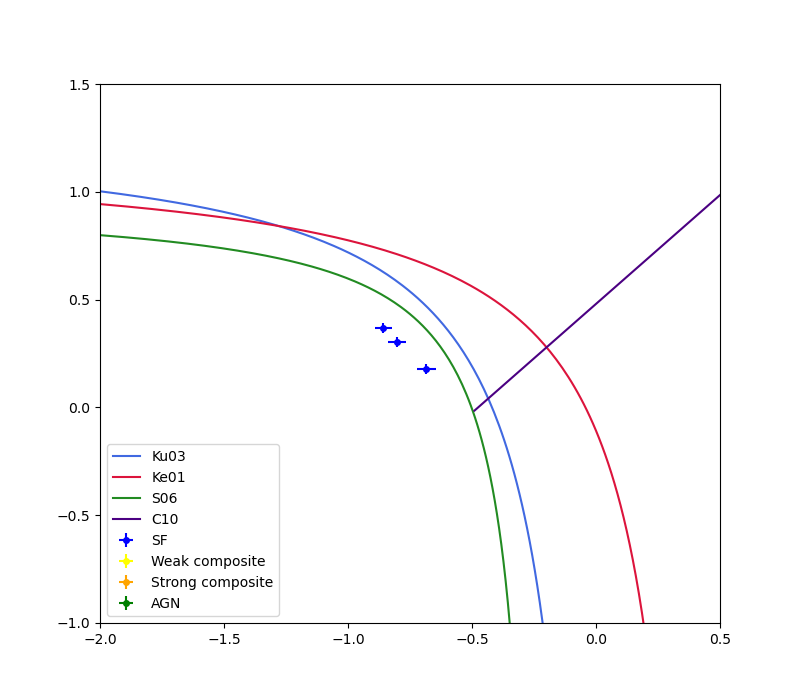

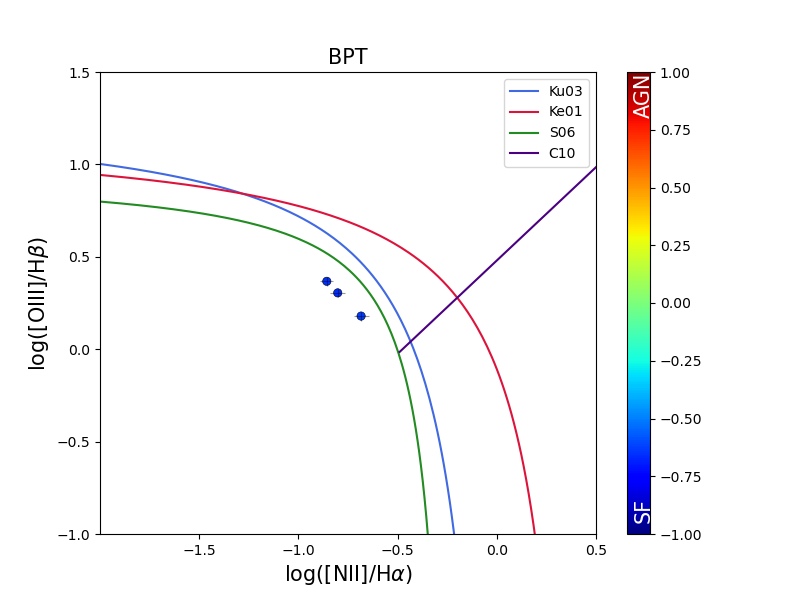

In [6]:
NII_HA =[]
OIII_HB =[]
SII_HA =[]
NII_HA_err =[]
OIII_HB_err =[]
SII_HA_err =[]
for i in range(len(spectra)):
    SNR = evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
    if SNR == True: 
        spectrum = spectra[i]
        oiii_hb, nii_ha, sii_ha, err_oiii_hb, err_nii_ha, err_sii_ha = log_ratio(spectrum)
        if np.isnan(oiii_hb) == False:
            OIII_HB.append(oiii_hb)
            OIII_HB_err.append(err_oiii_hb)
        if np.isnan(sii_ha) == False:
            SII_HA.append(sii_ha)
            SII_HA_err.append(err_sii_ha)
        if np.isnan(nii_ha) == False:    
            NII_HA.append(nii_ha)
            NII_HA_err.append(err_nii_ha)
    
    else: 
        oiii_hb = np.nan
        nii_ha = np.nan
        sii_ha = np.nan
        err_oiii_hb = np.nan
        err_nii_ha = np.nan
        err_sii_ha = np.nan
        NII_HA.append(nii_ha)
        OIII_HB.append(oiii_hb)
        SII_HA.append(sii_ha)
        NII_HA_err.append(err_nii_ha)
        OIII_HB_err.append(err_oiii_hb)
        SII_HA_err.append(err_sii_ha)
        print('Nan:', i+1)
        print(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
        
OIII_HB_ok = []
SII_HA_ok = []
NII_HA_ok = []
OIII_HB_err_ok = []
SII_HA_err_ok = []
NII_HA_err_ok = []

for i in range(len(spectra)):
    if np.isnan(OIII_HB[i]) == False:
        OIII_HB_ok.append(OIII_HB[i])
        OIII_HB_err_ok.append(OIII_HB_err[i])
    if np.isnan(SII_HA[i]) == False:
        SII_HA_ok.append(SII_HA[i])
        SII_HA_err_ok.append(SII_HA_err[i])
    if np.isnan(NII_HA[i]) == False:
        NII_HA_ok.append(NII_HA[i])
        NII_HA_err_ok.append(NII_HA_err[i])
        
NII_HA_ok = np.array(NII_HA_ok)
OIII_HB_ok = np.array(OIII_HB_ok)
NII_HA_err_ok = np.array(NII_HA_err_ok)
OIII_HB_err_ok = np.array(OIII_HB_err_ok)

plotBPT(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok)

# 4. Diagramma con gradiente continuo
plotBPT_gradient(NII_HA_ok, OIII_HB_ok, OIII_HB_err_ok, NII_HA_err_ok)